In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:

data= pd.read_csv('Insurance_claims.csv')

In [3]:
data.head()

,case_id,activity_name,timestamp,claimant_name,agent_name,adjuster_name,claim_amount,claimant_age,type_of_policy,car_make,car_model,car_year,type_of_accident,user_type
0,a626bc58-a7b2-4eff-aca9-2a622cd0c492,First Notification of Loss (FNOL),2020-09-24 14:08:42.423530,Karen Lopez,Thomas Cantu,Ian Garcia,1914.96,75,Collision,Honda,Civic,2012,Rollover,RPA
1,a626bc58-a7b2-4eff-aca9-2a622cd0c492,Assign Claim,2020-10-13 03:51:28.627923,Karen Lopez,Thomas Cantu,Ian Garcia,1914.96,75,Collision,Honda,Civic,2012,Rollover,RPA
2,a626bc58-a7b2-4eff-aca9-2a622cd0c492,Claim Decision,2020-10-14 22:30:14.948970,Karen Lopez,Thomas Cantu,Ian Garcia,1914.96,75,Collision,Honda,Civic,2012,Rollover,RPA
3,a626bc58-a7b2-4eff-aca9-2a622cd0c492,Set Reserve,2020-10-24 11:49:39.053890,Karen Lopez,Thomas Cantu,Ian Garcia,1914.96,75,Collision,Honda,Civic,2012,Rollover,RPA
4,a626bc58-a7b2-4eff-aca9-2a622cd0c492,Payment Sent,2020-10-27 05:46:04.378718,Karen Lopez,Thomas Cantu,Ian Garcia,1914.96,75,Collision,Honda,Civic,2012,Rollover,RPA


In [4]:
data.info()
data.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180000 entries, 0 to 179999
Data columns (total 14 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   case_id           180000 non-null  object 
 1   activity_name     180000 non-null  object 
 2   timestamp         180000 non-null  object 
 3   claimant_name     180000 non-null  object 
 4   agent_name        180000 non-null  object 
 5   adjuster_name     180000 non-null  object 
 6   claim_amount      180000 non-null  float64
 7   claimant_age      180000 non-null  int64  
 8   type_of_policy    180000 non-null  object 
 9   car_make          180000 non-null  object 
 10  car_model         180000 non-null  object 
 11  car_year          180000 non-null  int64  
 12  type_of_accident  180000 non-null  object 
 13  user_type         180000 non-null  object 
dtypes: float64(1), int64(2), object(11)
memory usage: 19.2+ MB


,claim_amount,claimant_age,car_year
count,180000.000000,180000.000000,180000.000000
mean,5498.598991,51.510233,2016.034367
std,2601.273015,19.691143,3.745014
min,1000.280000,18.000000,2010.000000
25%,3242.482500,34.000000,2013.000000
50%,5498.965000,52.000000,2016.000000
75%,7758.817500,69.000000,2019.000000
max,9999.470000,85.000000,2022.000000


In [5]:
data.isna().sum()

case_id             0
activity_name       0
timestamp           0
claimant_name       0
agent_name          0
adjuster_name       0
claim_amount        0
claimant_age        0
type_of_policy      0
car_make            0
car_model           0
car_year            0
type_of_accident    0
user_type           0
dtype: int64

In [6]:
data=data.drop_duplicates()

In [7]:
data["timestamp"] = pd.to_datetime(data["timestamp"])

In [8]:
data.dtypes

case_id                     object
activity_name               object
timestamp           datetime64[ns]
claimant_name               object
agent_name                  object
adjuster_name               object
claim_amount               float64
claimant_age                 int64
type_of_policy              object
car_make                    object
car_model                   object
car_year                     int64
type_of_accident            object
user_type                   object
dtype: object

In [9]:
# trie des evènements par case_id et timestamp
data = data.sort_values(by=["case_id", "timestamp"])

In [10]:
# nbre de dossiers uniques
data["case_id"].nunique()

30000

In [11]:
# nbre d'évènements par dossier
events_per_case = data.groupby("case_id").size()
events_per_case.describe()

count    30000.0
mean         6.0
std          0.0
min          6.0
25%          6.0
50%          6.0
75%          6.0
max          6.0
dtype: float64

In [12]:
# Nettoyage des Activités 

#Suppression des espaces
data["activity_name"] = data["activity_name"].str.strip()

# Uniformisation du texte 
data["activity_name"] = data["activity_name"].str.title()

# voir les activités existantes
data["activity_name"].unique()

array(['First Notification Of Loss (Fnol)', 'Assign Claim',
       'Claim Decision', 'Set Reserve', 'Payment Sent', 'Close Claim'],
      dtype=object)

In [13]:
# Analyse des variables catégorielles
categorical_columns = ["activity_name","type_of_policy","car_make","type_of_accident","user_type"]
for col in categorical_columns:
    print("\nDistribution of", col)
    print(data[col].value_counts())


Distribution of activity_name
activity_name
First Notification Of Loss (Fnol)    30000
Assign Claim                         30000
Claim Decision                       30000
Set Reserve                          30000
Payment Sent                         30000
Close Claim                          30000
Name: count, dtype: int64

Distribution of type_of_policy
type_of_policy
Collision        60126
Comprehensive    60018
Liability        59856
Name: count, dtype: int64

Distribution of car_make
car_make
Ford         26640
Toyota       26376
Honda        25716
Jeep         25632
Chevrolet    25554
Hyundai      25188
Nissan       24894
Name: count, dtype: int64

Distribution of type_of_accident
type_of_accident
Side-impact    45660
Head-on        44994
Rear-end       44946
Rollover       44400
Name: count, dtype: int64

Distribution of user_type
user_type
Human    116400
RPA       63600
Name: count, dtype: int64


In [14]:
# Analyse des valeurs numériques
numerical_columns = ["claim_amount","claimant_age","car_year"]
data[numerical_columns].describe()

,claim_amount,claimant_age,car_year
count,180000.000000,180000.000000,180000.000000
mean,5498.598991,51.510233,2016.034367
std,2601.273015,19.691143,3.745014
min,1000.280000,18.000000,2010.000000
25%,3242.482500,34.000000,2013.000000
50%,5498.965000,52.000000,2016.000000
75%,7758.817500,69.000000,2019.000000
max,9999.470000,85.000000,2022.000000


In [15]:
# Calcul de la durée des processus
process_durations = data.groupby("case_id")["timestamp"].agg(["min", "max"])

process_durations["duration_days"] = (process_durations["max"] - process_durations["min"]).dt   .total_seconds() / (24 * 3600)
process_durations.describe()

,min,max,duration_days
count,30000,30000,30000.000000
mean,2021-10-09 12:11:08.202444544,2021-11-13 12:33:09.570915584,35.015294
min,2020-04-06 07:50:45.322658,2020-05-03 01:57:58.656872,16.903979
25%,2021-01-07 19:01:05.304800,2021-02-11 10:02:13.098419200,31.973660
50%,2021-10-10 07:07:59.356129024,2021-11-14 16:25:06.602764032,35.026091
75%,2022-07-11 00:49:36.593678848,2022-08-14 19:45:58.349171456,38.035351
max,2023-04-15 13:40:34.644530,2023-05-26 01:49:58.261710,54.124193
std,NaN,NaN,4.478180


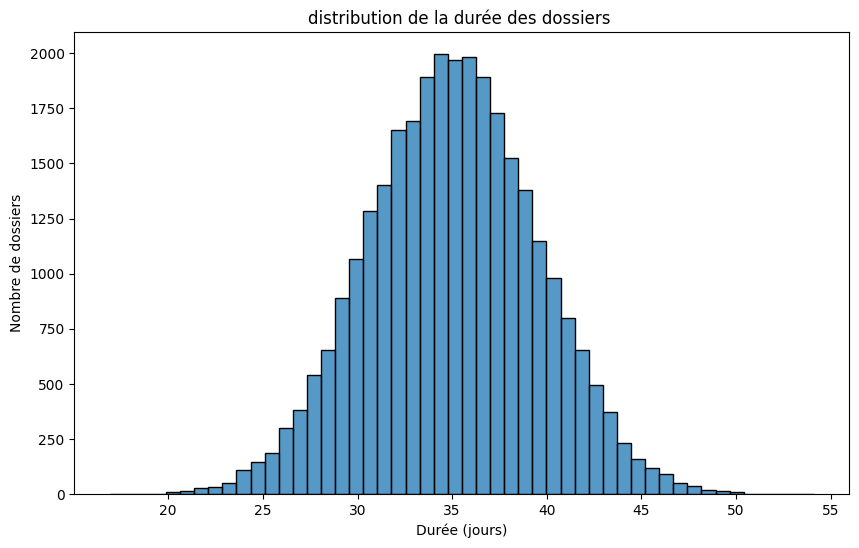

In [16]:
# Visualisation de la durée des dossiers
plt.figure(figsize=(10, 6))
sns.histplot(process_durations["duration_days"], bins=50)
plt.title("distribution de la durée des dossiers ")
plt.xlabel("Durée (jours)")
plt.ylabel("Nombre de dossiers")
plt.show()

In [17]:
# Sauvegarde du dataset nettoyé
data.to_csv("cleaned_insurance_claims.csv", index=False)
print("dataset nettoyé sauvegardé sous 'cleaned_insurance_claims.csv'")

dataset nettoyé sauvegardé sous 'cleaned_insurance_claims.csv'
